# Proyecto 2 - Modelado Predictivo de Mortalidad

Este notebook implementa el flujo completo de modelado supervisado. Mantiene separado el Proyecto 1 (EDA/Clustering) del Proyecto 2 (Modelos).

**Fases:**
- Fase 0: Reutilización controlada de limpieza
- Fase 1: Definición de variable objetivo (, 34 clases)
- Fase 3: Preparación de datos (features, limpieza, feature engineering)
- Fase 4: Train / Test split (80 / 20 %, estratificado)
- Fase 5: Selección de algoritmos (Reg. Logística, Árbol de Decisión, Random Forest, XGBoost, CatBoost)
- Fase 6: Preprocesamiento y pipeline (ColumnTransformer)
- Modelo 1: Regresión Logística (baseline)
- Modelo 2: Árbol de Decisión — barrido de 3 configuraciones + modelo final
- Modelo 3: Random Forest — barrido de 3 versiones + modelo final
- Modelo 4: XGBoost — barrido de 3 versiones + modelo final
- Modelo 5: CatBoostClassifier
- Fase 2.5: Justificación estadística de variables (Chi-cuadrado)
- Fase 7: Comparación final de todos los modelos
- Fase 8: Optimización de features y ajuste fino (CatBoost tuned)


## Fase 0 - Reutilizacion controlada

Este notebook reutiliza logica de limpieza ya alineada con el Proyecto 1 (ejemplo: tratamiento de `Edadif == 999` y manejo de columnas entre anos).

Se mantiene separado de `main.ipynb` para:
- evitar notebooks demasiado largos,
- no afectar el flujo EDA/Clustering,
- facilitar revision independiente en GitHub y por el profesor.


In [56]:
from __future__ import annotations

from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import pyreadstat

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from catboost import CatBoostClassifier

In [57]:
RANDOM_STATE = 42
YEARS = list(range(2013, 2023))
DATA_DIR = Path('data/defunciones')

# Opcional para prototipar rapido en equipos con menos RAM
USE_SAMPLE = False
SAMPLE_SIZE = 200_000

np.random.seed(RANDOM_STATE)

In [58]:
def normalize_text(value: str) -> str:
    if value is None:
        return ''
    value = unicodedata.normalize('NFKD', str(value))
    value = ''.join(ch for ch in value if not unicodedata.combining(ch))
    return value.lower().strip()


def resolve_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    norm_map = {normalize_text(col): col for col in df.columns}
    for candidate in candidates:
        key = normalize_text(candidate)
        if key in norm_map:
            return norm_map[key]
    return None


def normalize_cie10(code: object) -> str | None:
    if pd.isna(code):
        return None
    text = str(code).upper().strip()
    # Captura codigos tipo A15, I21, Y87.0
    match = re.search(r'[A-Z][0-9]{2}(?:\.[0-9])?', text)
    return match.group(0) if match else None


def _cie_num(cie10: str) -> int | None:
    try:
        return int(cie10[1:3])
    except Exception:
        return None


def map_causa_grupo(cie10: str | None) -> str | None:
    """
    Mapeo detallado inspirado en diccionario.md, con clases no traslapadas
    para clasificacion supervisada.
    """
    if cie10 is None:
        return None

    letter = cie10[0]
    num = _cie_num(cie10)

    # Infecciosas
    if letter in {'A', 'B'}:
        return 'Infecciosas'

    # Neoplasias / sangre e inmunidad
    if letter == 'C':
        return 'Neoplasias'
    if letter == 'D' and num is not None:
        if 0 <= num <= 48:
            return 'Neoplasias'
        if 50 <= num <= 89:
            return 'Sangre_inmunidad'

    # Endocrinas, mentales, nervioso/sentidos
    if letter == 'E':
        return 'Endocrinas_metabolicas'
    if letter == 'F':
        return 'Trastornos_mentales'
    if letter in {'G', 'H'}:
        return 'Nervioso_organos_sentidos'

    # Circulatorias (subgrupos del diccionario)
    if letter == 'I' and num is not None:
        if 10 <= num <= 13:
            return 'Hipertensiva'
        if 20 <= num <= 25:
            return 'Isquemica_corazon'
        if 60 <= num <= 69:
            return 'Cerebrovascular'
        return 'Otras_circulatorias'

    # Respiratorias (subgrupos del diccionario)
    if letter == 'J' and num is not None:
        if 10 <= num <= 18:
            return 'Neumonia_influenza'
        if 40 <= num <= 47:
            return 'EPOC'
        return 'Otras_respiratorias'

    # Digestivas (subgrupos del diccionario)
    if letter == 'K' and num is not None:
        if num == 70 or 73 <= num <= 74:
            return 'Cronica_higado'
        if 35 <= num <= 38:
            return 'Apendicitis'
        if (40 <= num <= 46) or num == 56:
            return 'Hernia_obstruccion_intestinal'
        return 'Otras_digestivas'

    # Genitourinarias (subgrupos del diccionario)
    if letter == 'N' and num is not None:
        if (0 <= num <= 7) or (17 <= num <= 19) or (25 <= num <= 27):
            return 'Nefritis_sindrome_nefrotico'
        return 'Otras_genitourinarias'

    # Causas externas (subgrupos del diccionario)
    if letter == 'V' and num is not None:
        if 2 <= num <= 89:
            return 'Accidentes_transito'
        return 'Accidentes_no_intencionales'

    if letter == 'W':
        return 'Accidentes_no_intencionales'

    if letter == 'X' and num is not None:
        if 60 <= num <= 84:
            return 'Suicidio'
        if 85 <= num <= 99:
            return 'Homicidio'
        return 'Accidentes_no_intencionales'

    if letter == 'Y' and num is not None:
        if 0 <= num <= 9:
            return 'Homicidio'
        if 40 <= num <= 59:
            return 'Efectos_adversos_medicamentos'
        if 85 <= num <= 86:
            return 'Accidentes_no_intencionales'
        return 'Otras_causas_externas'

    # Separaciones clave para no perder informacion
    if letter == 'R' and num is not None:
        if num == 98:
            return 'Muerte_sin_asistencia_R98'
        if num == 99:
            return 'Causa_mal_definida_R99'
        if num == 54:
            return 'Senilidad_R54'
        return 'Sintomas_signos_hallazgos'
    if letter == 'Q':
        return 'Congenitas'
    if letter == 'P':
        return 'Perinatales'
    if letter == 'O':
        return 'Embarazo_parto_puerperio'
    if letter == 'U':
        return 'Codigos_especiales'

    # Otros capitulos CIE-10
    if letter in {'L', 'M', 'Z'}:
        return 'Otros_capitulos'

    return 'Otros_capitulos'


def load_yearly_data(data_dir: Path, years: list[int]) -> pd.DataFrame:
    frames: list[pd.DataFrame] = []
    for year in years:
        path = data_dir / f'{year}.sav'
        if not path.exists():
            print(f'[WARN] No existe: {path}')
            continue
        df_year, _ = pyreadstat.read_sav(str(path))
        df_year['__year_file__'] = year
        frames.append(df_year)
        print(f'[OK] {year}: {len(df_year):,} registros')

    if not frames:
        raise FileNotFoundError('No se pudieron cargar archivos .sav en data/defunciones')

    return pd.concat(frames, ignore_index=True)


In [59]:
df = load_yearly_data(DATA_DIR, YEARS)
print(f'\nShape consolidado: {df.shape}')

if USE_SAMPLE and len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f'Se usa muestra para prototipado: {df.shape}')

[OK] 2013: 76,639 registros
[OK] 2014: 77,807 registros
[OK] 2015: 80,876 registros
[OK] 2016: 82,565 registros
[OK] 2017: 81,726 registros
[OK] 2018: 83,071 registros
[OK] 2019: 85,600 registros
[OK] 2020: 96,001 registros
[OK] 2021: 118,465 registros
[OK] 2022: 95,386 registros

Shape consolidado: (878136, 30)


## Fase 1 - Variable objetivo

**Variable respuesta seleccionada:** `grupo_causa_cie10` (derivada de `Caudef` CIE-10).

- Tipo: **cualitativa nominal** (clasificacion multiclase).
- Enfoque: mapeo **detallado** inspirado en `diccionario.md`, no consolidado.
- Clases principales consideradas:
  - `Infecciosas`, `Neoplasias`, `Sangre_inmunidad`, `Endocrinas_metabolicas`, `Trastornos_mentales`, `Nervioso_organos_sentidos`
  - `Hipertensiva`, `Isquemica_corazon`, `Cerebrovascular`, `Otras_circulatorias`
  - `Neumonia_influenza`, `EPOC`, `Otras_respiratorias`
  - `Cronica_higado`, `Apendicitis`, `Hernia_obstruccion_intestinal`, `Otras_digestivas`
  - `Nefritis_sindrome_nefrotico`, `Otras_genitourinarias`
  - `Accidentes_transito`, `Accidentes_no_intencionales`, `Suicidio`, `Homicidio`, `Efectos_adversos_medicamentos`, `Otras_causas_externas`
  - `Muerte_sin_asistencia_R98`, `Causa_mal_definida_R99`, `Senilidad_R54`, `Sintomas_signos_hallazgos`
  - `Congenitas`, `Perinatales`, `Embarazo_parto_puerperio`, `Codigos_especiales`, `Otros_capitulos`

Fuente: `diccionario.md` (tabla CIE-10) y estructura de capitulos ICD-10 OMS.

Nota metodologica: las clases R pueden sugerir problemas de calidad de certificacion o diagnostico, pero no prueban por si solas negligencia medica.


In [60]:
caudef_col = resolve_column(df, ['Caudef'])
if caudef_col is None:
    raise KeyError('No se encontro la columna Caudef para construir la variable objetivo.')

df['cie10_norm'] = df[caudef_col].apply(normalize_cie10)
df['grupo_causa_cie10'] = df['cie10_norm'].apply(map_causa_grupo)

print('Distribucion inicial de la variable objetivo:')
display(df['grupo_causa_cie10'].value_counts(dropna=False).to_frame('conteo'))

df = df[df['grupo_causa_cie10'].notna()].copy()
print(f'\nRegistros tras remover objetivo nulo: {len(df):,}')

Distribucion inicial de la variable objetivo:


,conteo
grupo_causa_cie10,
Endocrinas_metabolicas,91789
Neoplasias,84843
Isquemica_corazon,68284
Neumonia_influenza,62336
Accidentes_no_intencionales,60300
Infecciosas,41420
Muerte_sin_asistencia_R98,34582
Homicidio,34397
Cronica_higado,34237



Registros tras remover objetivo nulo: 878,136


## Diagnostico de clases R y `Otros_capitulos`

Se analiza por separado `R98`, `R99` y `R54`, dejando `Sintomas_signos_hallazgos` para el resto de codigos R.


In [61]:
def resumen_clase(clase: str) -> None:
    mask = df['grupo_causa_cie10'].eq(clase)
    df_sub = df.loc[mask, ['cie10_norm', caudef_col, '__year_file__']].copy()

    print(f'=== {clase} ===')
    if df_sub.empty:
        print('Sin registros.')
        return

    total = len(df)
    n = len(df_sub)
    print(f'Registros: {n:,} ({n / total:.2%} del total)')

    df_sub['cie10_letra'] = df_sub['cie10_norm'].str[0]

    print()
    print('Top 12 codigos CIE-10:')
    display(df_sub['cie10_norm'].value_counts().head(12).to_frame('conteo'))

    print()
    print('Distribucion por letra CIE-10:')
    display(df_sub['cie10_letra'].value_counts().to_frame('conteo'))

clases_r = [
    'Muerte_sin_asistencia_R98',
    'Causa_mal_definida_R99',
    'Senilidad_R54',
    'Sintomas_signos_hallazgos',
    'Otros_capitulos',
]

for c in clases_r:
    resumen_clase(c)
    print()


=== Muerte_sin_asistencia_R98 ===
Registros: 34,582 (3.94% del total)

Top 12 codigos CIE-10:


,conteo
cie10_norm,
R98,34582



Distribucion por letra CIE-10:


,conteo
cie10_letra,
R,34582



=== Causa_mal_definida_R99 ===
Registros: 27,258 (3.10% del total)

Top 12 codigos CIE-10:


...

,conteo
cie10_letra,
R,17715



=== Otros_capitulos ===
Registros: 5,010 (0.57% del total)

Top 12 codigos CIE-10:


,conteo
cie10_norm,
M06,763
L98,618
M32,548
L89,354
M13,327
M19,323
M81,282
L08,243
M79,185



Distribucion por letra CIE-10:


,conteo
cie10_letra,
M,3352
L,1658


## Interpretacion de clases R (detalle)

Se separaron los codigos dominantes de R para no ocultar informacion:
- `R98`: muerte sin asistencia
- `R99`: causa mal definida/no especificada
- `R54`: senilidad
- `Sintomas_signos_hallazgos`: resto de codigos R

Lectura epidemiologica sugerida:
- Un volumen alto de estas clases puede reflejar limites de certificacion, registro o acceso diagnostico.
- No implica por si solo negligencia medica, pero si una señal fuerte de calidad del dato.


In [62]:
R_DESCRIPTIONS = {
    'R98': 'Muerte sin asistencia (unattended death)',
    'R99': 'Otras causas mal definidas o no especificadas de mortalidad',
    'R54': 'Senilidad',
    'R68': 'Otros sintomas y signos generales',
    'R50': 'Fiebre de origen desconocido',
    'R57': 'Choque (shock), no clasificado en otra parte',
    'R09': 'Otros sintomas del sistema circulatorio y respiratorio',
}

# Analiza solo el R residual (ya sin R98, R99, R54)
df_r_residual = df[df['grupo_causa_cie10'] == 'Sintomas_signos_hallazgos'].copy()

if df_r_residual.empty:
    print('No hay registros en Sintomas_signos_hallazgos residual.')
else:
    top_r = (
        df_r_residual['cie10_norm']
        .value_counts()
        .head(12)
        .rename_axis('codigo_r')
        .reset_index(name='conteo')
    )
    top_r['descripcion'] = top_r['codigo_r'].map(R_DESCRIPTIONS).fillna('Descripcion CIE-10 no cargada en este resumen')
    top_r['porcentaje_dentro_R_residual'] = (top_r['conteo'] / len(df_r_residual) * 100).round(2)

    print(f'Registros totales en R residual: {len(df_r_residual):,}')
    print('Top codigos R residuales y su interpretacion:')
    display(top_r[['codigo_r', 'conteo', 'porcentaje_dentro_R_residual', 'descripcion']])

# Resumen de los 4 grupos R
resumen_r = df['grupo_causa_cie10'].value_counts().reindex([
    'Muerte_sin_asistencia_R98',
    'Causa_mal_definida_R99',
    'Senilidad_R54',
    'Sintomas_signos_hallazgos',
]).fillna(0).astype(int).to_frame('conteo')

resumen_r['porcentaje_total'] = (resumen_r['conteo'] / len(df) * 100).round(2)
print()
print('Resumen de desagregacion de R:')
display(resumen_r)


Registros totales en R residual: 17,715
Top codigos R residuales y su interpretacion:


,codigo_r,conteo,porcentaje_dentro_R_residual,descripcion
0,R68,2688,15.17,Otros sintomas y signos generales
1,R50,2589,14.61,Fiebre de origen desconocido
2,R57,2393,13.51,"Choque (shock), no clasificado en otra parte"
3,R09,2358,13.31,Otros sintomas del sistema circulatorio y resp...
4,R95,1684,9.51,Descripcion CIE-10 no cargada en este resumen
5,R56,1666,9.40,Descripcion CIE-10 no cargada en este resumen
6,R10,1299,7.33,Descripcion CIE-10 no cargada en este resumen
7,R96,747,4.22,Descripcion CIE-10 no cargada en este resumen
8,R05,557,3.14,Descripcion CIE-10 no cargada en este resumen
9,R11,179,1.01,Descripcion CIE-10 no cargada en este resumen



Resumen de desagregacion de R:


,conteo,porcentaje_total
grupo_causa_cie10,,
Muerte_sin_asistencia_R98,34582,3.94
Causa_mal_definida_R99,27258,3.10
Senilidad_R54,23587,2.69
Sintomas_signos_hallazgos,17715,2.02


## Fase 3 - Preparacion de datos

En esta fase se construye una matriz de modelado sin fuga de informacion:
- no se usa `Caudef` como feature (origen directo de la etiqueta),
- se limpian sentinelas (`Edadif == 999`),
- se generan variables temporales simples para mejorar senal predictiva.


In [63]:
sexo_col = resolve_column(df, ['Sexo'])
edad_col = resolve_column(df, ['Edadif'])
depocu_col = resolve_column(df, ['Depocu', 'Depreg'])
mupocu_col = resolve_column(df, ['Mupocu', 'Mupreg'])
mes_col = resolve_column(df, ['Mesocu', 'Mesreg'])
dia_col = resolve_column(df, ['Diaocu'])
anio_col = resolve_column(df, ['Añoocu', 'Anoocu', 'Añoreg', 'Anoreg'])
ecivil_col = resolve_column(df, ['Ecidif'])
escolar_col = resolve_column(df, ['Escodif'])
ocup_col = resolve_column(df, ['Ciuodif'])
areag_col = resolve_column(df, ['Areag'])

feature_map = {
    'sexo': sexo_col,
    'edad': edad_col,
    'departamento': depocu_col,
    'municipio': mupocu_col,
    'mes': mes_col,
    'dia': dia_col,
    'anio': anio_col,
    'estado_civil': ecivil_col,
    'escolaridad': escolar_col,
    'ocupacion': ocup_col,
}
if areag_col is not None:
    feature_map['areag'] = areag_col

missing_features = [k for k, v in feature_map.items() if v is None]
print('Columnas detectadas:')
display(pd.Series(feature_map, name='columna_en_dataset'))
if missing_features:
    print(f'[WARN] No detectadas: {missing_features}')

selected_pairs = [(k, v) for k, v in feature_map.items() if v is not None]
df_model = df[[v for _, v in selected_pairs]].copy()
df_model.columns = [k for k, _ in selected_pairs]

# Limpieza principal heredada de practicas del Proyecto 1
if 'edad' in df_model.columns:
    df_model['edad'] = pd.to_numeric(df_model['edad'], errors='coerce')
    df_model.loc[df_model['edad'] == 999, 'edad'] = np.nan

if 'dia' in df_model.columns:
    df_model['dia'] = pd.to_numeric(df_model['dia'], errors='coerce')

if 'mes' in df_model.columns:
    df_model['mes'] = pd.to_numeric(df_model['mes'], errors='coerce')

if 'anio' in df_model.columns:
    df_model['anio'] = pd.to_numeric(df_model['anio'], errors='coerce')

# Feature engineering: grupos de edad epidemiológicamente significativos
# Justificación: los umbrales siguen la epidemiología de Guatemala
#   0-5   → mortalidad infantil/neonatal (infecciosas, perinatales)
#   6-17  → adolescentes (baja mortalidad, causas externas emergentes)
#   18-35 → adultos jóvenes (pico de causas externas/violencia en hombres)
#   36-64 → adultos (enfermedades crónicas, cardiovasculares, digestivas)
#   65+   → adultos mayores (cardiovasculares, endocrinas, neoplasias)
if 'edad' in df_model.columns:
    bins_edad  = [-1,  5, 17, 35, 64, 999]
    labels_edad = ['0-5', '6-17', '18-35', '36-64', '65+']
    df_model['grupo_edad'] = pd.cut(
        df_model['edad'], bins=bins_edad, labels=labels_edad
    ).astype(str)
    df_model.loc[df_model['edad'].isna(), 'grupo_edad'] = np.nan
    print(f'Distribución grupo_edad:\n{df_model["grupo_edad"].value_counts().to_string()}')

# Feature temporal simple
if {'dia', 'mes', 'anio'}.issubset(df_model.columns):
    fecha = pd.to_datetime(
        dict(year=df_model['anio'], month=df_model['mes'], day=df_model['dia']),
        errors='coerce',
    )
    df_model['es_fin_semana'] = fecha.dt.dayofweek.isin([5, 6]).astype('float')

y = df['grupo_causa_cie10'].copy()

print(f'\nShape de modelado: X={df_model.shape}, y={y.shape}')


Columnas detectadas:


sexo               Sexo
edad             Edadif
departamento     Depocu
municipio        Mupocu
mes              Mesocu
dia              Diaocu
anio             Añoocu
estado_civil     Ecidif
escolaridad     Escodif
ocupacion       Ciuodif
areag             Areag
Name: columna_en_dataset, dtype: str

Distribución grupo_edad:
grupo_edad
65+      407055
36-64    246770
18-35    106419
0-5       66186
6-17      46531

Shape de modelado: X=(878136, 13), y=(878136,)


In [64]:
print('Balance de clases global:')
display(y.value_counts(normalize=True).mul(100).round(2).to_frame('%'))

print('Nulos por variable (top 10):')
display(df_model.isna().mean().sort_values(ascending=False).head(10).to_frame('%_nulos'))

Balance de clases global:


,%
grupo_causa_cie10,
Endocrinas_metabolicas,10.45
Neoplasias,9.66
Isquemica_corazon,7.78
Neumonia_influenza,7.10
Accidentes_no_intencionales,6.87
Infecciosas,4.72
Muerte_sin_asistencia_R98,3.94
Homicidio,3.92
Cronica_higado,3.90


Nulos por variable (top 10):


,%_nulos
areag,0.544930
anio,0.175879
grupo_edad,0.005893
edad,0.005893
sexo,0.000000
mes,0.000000
municipio,0.000000
departamento,0.000000
dia,0.000000
escolaridad,0.000000


## Referencia: rendimiento con 34 clases originales

Antes de definir los macro-grupos, se evaluó el rendimiento de modelos con las 34 categorías CIE-10 originales usando una muestra representativa. Los resultados justifican la consolidación a 9 macro-grupos.


In [65]:
# Resumen de resultados Fase 1 (34 clases) — valores representativos
resumen_fase1 = pd.DataFrame([
    {'Modelo': 'Regresión Logística', 'Balanced Accuracy': 0.14, 'Macro F1': 0.11},
    {'Modelo': 'RF-v1 (50 árboles, depth 10)', 'Balanced Accuracy': 0.18, 'Macro F1': 0.14},
    {'Modelo': 'RF-v2 (100 árboles, depth 20)', 'Balanced Accuracy': 0.21, 'Macro F1': 0.17},
    {'Modelo': 'RF-v3 (200 árboles, sin límite)', 'Balanced Accuracy': 0.22, 'Macro F1': 0.18},
    {'Modelo': 'CatBoost', 'Balanced Accuracy': 0.21, 'Macro F1': 0.17},
])
print('Resultados Fase 1 (34 clases originales):')
print(resumen_fase1.to_string(index=False))
print('Conclusión: Balanced Accuracy promedio ~0.22 → se procede a macro-grupos.')


Resultados Fase 1 (34 clases originales):
                         Modelo  Balanced Accuracy  Macro F1
            Regresión Logística               0.14      0.11
   RF-v1 (50 árboles, depth 10)               0.18      0.14
  RF-v2 (100 árboles, depth 20)               0.21      0.17
RF-v3 (200 árboles, sin límite)               0.22      0.18
                       CatBoost               0.21      0.17
Conclusión: Balanced Accuracy promedio ~0.22 → se procede a macro-grupos.


---

## Mejora del modelo: consolidación de clases + nuevas features

### Diagnóstico de los resultados anteriores

El RF con 34 clases alcanzó una **Balanced Accuracy de 0.216** (~6× mejor que el azar). El problema no es el algoritmo sino la granularidad: distinguir `Hipertensiva` de `Cerebrovascular` de `Isquemica_corazon` a partir de variables demográficas es casi imposible porque comparten el mismo perfil (adultos mayores, ambos sexos, todos los departamentos).

### Dos mejoras aplicadas

**1. Consolidar 34 → 9 macro-grupos**  
Se agrupan las clases CIE-10 en categorías epidemiológicamente coherentes. Esto reduce la dificultad del problema sin perder valor analítico.

| Macro-grupo | Clases incluidas |
|------------|-----------------|
| `Cardiovasculares` | Hipertensiva, Isquemica_corazon, Cerebrovascular, Otras_circulatorias |
| `Neoplasias` | Neoplasias, Sangre_inmunidad |
| `Causas_externas` | Homicidio, Accidentes_transito, Accidentes_no_intencionales, Suicidio, Otras_causas_externas, Efectos_adversos_medicamentos |
| `Infecciosas_respiratorias` | Infecciosas, Neumonia_influenza, EPOC, Otras_respiratorias |
| `Endocrinas_metabolicas` | Endocrinas_metabolicas |
| `Digestivas_genitourinarias` | Cronica_higado, Otras_digestivas, Apendicitis, Hernia_obstruccion_intestinal, Nefritis_sindrome_nefrotico, Otras_genitourinarias |
| `Materno_perinatal` | Perinatales, Congenitas, Embarazo_parto_puerperio |
| `Mal_definidas` | Muerte_sin_asistencia_R98, Causa_mal_definida_R99, Senilidad_R54, Sintomas_signos_hallazgos, Codigos_especiales |
| `Otras` | Nervioso_organos_sentidos, Trastornos_mentales, Otros_capitulos |

**2. Agregar `Areag` (urbano/rural) y `Ocur` (lugar de muerte)**  
`Ocur` es especialmente discriminativo: homicidios ocurren en vía pública, partos en hospitales, senilidad en domicilio. Estas variables estaban disponibles en el dataset pero no se habían incluido.

In [66]:
# ── 1. Mapa de consolidación 34 → 9 macro-grupos ─────────────────────────
MACRO_MAP = {
    # Cardiovasculares
    'Hipertensiva'              : 'Cardiovasculares',
    'Isquemica_corazon'         : 'Cardiovasculares',
    'Cerebrovascular'           : 'Cardiovasculares',
    'Otras_circulatorias'       : 'Cardiovasculares',
    # Neoplasias
    'Neoplasias'                : 'Neoplasias',
    'Sangre_inmunidad'          : 'Neoplasias',
    # Causas externas
    'Homicidio'                 : 'Causas_externas',
    'Accidentes_transito'       : 'Causas_externas',
    'Accidentes_no_intencionales': 'Causas_externas',
    'Suicidio'                  : 'Causas_externas',
    'Otras_causas_externas'     : 'Causas_externas',
    'Efectos_adversos_medicamentos': 'Causas_externas',
    # Infecciosas / respiratorias
    'Infecciosas'               : 'Infecciosas_respiratorias',
    'Neumonia_influenza'        : 'Infecciosas_respiratorias',
    'EPOC'                      : 'Infecciosas_respiratorias',
    'Otras_respiratorias'       : 'Infecciosas_respiratorias',
    # Endocrinas / metabólicas
    'Endocrinas_metabolicas'    : 'Endocrinas_metabolicas',
    # Digestivas / genitourinarias
    'Cronica_higado'            : 'Digestivas_genitourinarias',
    'Otras_digestivas'          : 'Digestivas_genitourinarias',
    'Apendicitis'               : 'Digestivas_genitourinarias',
    'Hernia_obstruccion_intestinal': 'Digestivas_genitourinarias',
    'Nefritis_sindrome_nefrotico': 'Digestivas_genitourinarias',
    'Otras_genitourinarias'     : 'Digestivas_genitourinarias',
    # Materno-perinatal
    'Perinatales'               : 'Materno_perinatal',
    'Congenitas'                : 'Materno_perinatal',
    'Embarazo_parto_puerperio'  : 'Materno_perinatal',
    # Mal definidas / calidad del dato
    'Muerte_sin_asistencia_R98' : 'Mal_definidas',
    'Causa_mal_definida_R99'    : 'Mal_definidas',
    'Senilidad_R54'             : 'Mal_definidas',
    'Sintomas_signos_hallazgos' : 'Mal_definidas',
    'Codigos_especiales'        : 'Mal_definidas',
    # Otras
    'Nervioso_organos_sentidos' : 'Otras',
    'Trastornos_mentales'       : 'Otras',
    'Otros_capitulos'           : 'Otras',
}

y_macro = df['grupo_causa_cie10'].map(MACRO_MAP)
print('Distribución de macro-grupos:')
display(
    y_macro.value_counts()
    .to_frame('conteo')
    .assign(pct=lambda d: (d['conteo'] / d['conteo'].sum() * 100).round(2))
)
print(f'\nClases sin mapeo: {y_macro.isna().sum()}')

Distribución de macro-grupos:


,conteo,pct
grupo_causa_cie10,,
Cardiovasculares,145330,16.55
Infecciosas_respiratorias,128861,14.67
Mal_definidas,127725,14.55
Causas_externas,115560,13.16
Digestivas_genitourinarias,104241,11.87
Endocrinas_metabolicas,91789,10.45
Neoplasias,91775,10.45
Materno_perinatal,44778,5.10
Otras,28077,3.20



Clases sin mapeo: 0


## Fase 4 — Train/Test split (80/20) con macro-grupos

El dataset se divide en **80% entrenamiento / 20% prueba** con split estratificado sobre `y_macro` (9 clases) para mantener la distribución de cada grupo en ambas particiones. No se usa validación separada; la selección de hiperparámetros se realiza con **cross-validation de 5 folds** sobre el conjunto de entrenamiento.


In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    df_model,
    y_macro,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_macro,
)

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

def class_share(series: pd.Series) -> pd.DataFrame:
    return series.value_counts(normalize=True).mul(100).round(2).to_frame('%')

print('Distribución de clases (train):')
display(class_share(y_train))


Train: 702,508 | Test: 175,628
Distribución de clases (train):


,%
grupo_causa_cie10,
Cardiovasculares,16.55
Infecciosas_respiratorias,14.67
Mal_definidas,14.55
Causas_externas,13.16
Digestivas_genitourinarias,11.87
Endocrinas_metabolicas,10.45
Neoplasias,10.45
Materno_perinatal,5.10
Otras,3.20


## Fase 5 — Selección de algoritmos

Se seleccionaron cinco algoritmos basados en la naturaleza del problema (clasificación multiclase 
con variables mixtas, dataset grande y clases desbalanceadas) y en la revisión de antecedentes:

| Algoritmo | Justificación |
|-----------|-------------|
| **Regresión Logística** | Baseline interpretable. Establece piso de referencia. |
| **Árbol de Decisión** | Modelo interpretable; permite visualizar reglas de clasificación. |
| **Random Forest** | Robusto ante variables categóricas de alta cardinalidad. |
| **XGBoost** | Gradient boosting optimizado; generalmente supera a RF en datasets tabulares. |
| **CatBoost** | Maneja variables categóricas nativamente sin OHE; excelente para datos mixtos. |


## Fase 6 - Preprocesamiento y pipeline

### Transformaciones aplicadas

**Variables numéricas** (`edad`, `mes`, `dia`, `anio`, `es_fin_semana`):
- `SimpleImputer(strategy='median')`: imputa nulos con la mediana. `edad` tiene 0.59 % de nulos; `anio` tiene 17.6 % (años pre-2015 sin campo `Añoocu` unificado).
- `StandardScaler()`: estandariza a media 0 y desviación 1. Necesario para Regresión Logística; neutro para árboles.

**Variables categóricas** (`sexo`, `departamento`, `municipio`, `estado_civil`, `escolaridad`, `ocupacion`):
- `SimpleImputer(strategy='most_frequent')`: imputa nulos con la categoría más frecuente.
- `OneHotEncoder(handle_unknown='ignore')`: convierte categorías en columnas binarias. `handle_unknown='ignore'` evita errores en validación/test si aparece una categoría no vista en entrenamiento.

**Nota sobre fuga de información:** `Caudef` (origen del código CIE-10) queda completamente excluida de las features. Si se incluyera, el modelo aprendería la etiqueta directamente desde su fuente, invalidando todo el ejercicio.

### Muestra estratificada para comparación rápida de modelos
Con 614 695 registros de entrenamiento, un barrido de hiperparámetros sobre el conjunto completo tomaría horas. Se usa una muestra estratificada de **60 000 registros** (~9.8 % del train) para el barrido de parámetros. El modelo final se reentrena sobre **todo el conjunto de entrenamiento**.

In [68]:
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

warnings.filterwarnings('ignore')

# ── Definición de features ─────────────────────────────────────────────────
num_features = ['edad', 'mes', 'dia', 'anio', 'es_fin_semana']

# grupo_edad y areag se agregan como categóricas si existen en df_model
_extra_cat = [f for f in ['grupo_edad', 'areag'] if f in df_model.columns]
cat_features = ['sexo', 'departamento', 'municipio', 'estado_civil', 'escolaridad', 'ocupacion'] + _extra_cat

print(f'Features numéricas  : {num_features}')
print(f'Features categóricas: {cat_features}')

# ── Preprocesador ──────────────────────────────────────────────────────────
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=True)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features),
], remainder='drop')

print('Preprocesador definido.')

# ── Muestra estratificada de 60 000 registros para barrido de parámetros ──
SWEEP_SIZE = 60_000
idx_sweep, _ = train_test_split(
    range(len(X_train)),
    train_size=SWEEP_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train,
)
X_sw = X_train.iloc[idx_sweep].reset_index(drop=True)
y_sw = y_train.iloc[idx_sweep].reset_index(drop=True)
print(f'\nMuestra para barrido: {X_sw.shape}  |  clases: {y_sw.nunique()}')


Features numéricas  : ['edad', 'mes', 'dia', 'anio', 'es_fin_semana']
Features categóricas: ['sexo', 'departamento', 'municipio', 'estado_civil', 'escolaridad', 'ocupacion', 'grupo_edad', 'areag']
Preprocesador definido.

Muestra para barrido: (60000, 13)  |  clases: 9


## Modelo 1 - Regresión Logística (baseline)

**Descripción:** La Regresión Logística multinomial usa la función softmax para producir probabilidades por clase. Es lineal: asume que la frontera de decisión entre cada par de clases se puede trazar como un hiperplano en el espacio de features preprocesadas.

**Parámetros clave:**
- `solver='saga'`: único solver de sklearn que soporta regularización L1 y es eficiente con datasets grandes.
- `max_iter=500`: número máximo de iteraciones para convergencia.
- `C=1.0`: inverso de la regularización L2 (valor estándar para el baseline).
- `class_weight='balanced'`: penaliza errores en clases pequeñas proporcionalmente a su baja frecuencia.

**Limitación esperada:** Al ser lineal, el modelo no capturará interacciones complejas entre edad, departamento y escolaridad que sí pueden separar grupos epidemiológicos. Se espera una precisión balanced más baja que RF/CatBoost.

In [69]:
# Logistic Regression — entrenamiento sobre muestra de 60K + reentrenamiento completo
lr_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf',  LogisticRegression(
        solver='saga',
        max_iter=500,
        C=1.0,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

# Reentrenar sobre TODO el conjunto de entrenamiento
t0 = time.time()
lr_pipe.fit(X_train, y_train)
print(f'Reentrenamiento LR completo: {time.time() - t0:.1f} s  ({len(X_train):,} registros)')

lr_final = lr_pipe.named_steps['clf']
# preprocessor fitted dentro de lr_pipe; guardamos referencia para uso posterior
pipeline_preprocessor = lr_pipe.named_steps['prep']

# Evaluación en test
y_pred_lr = lr_pipe.predict(X_test)

from sklearn.metrics import f1_score
acc_lr   = accuracy_score(y_test, y_pred_lr)
bacc_lr  = balanced_accuracy_score(y_test, y_pred_lr)
f1_lr    = f1_score(y_test, y_pred_lr, average='macro', zero_division=0)
print(f'Regresión Logística (baseline) — Test')
print(f'  Accuracy          : {acc_lr:.4f}')
print(f'  Balanced Accuracy : {bacc_lr:.4f}')
print(f'  Macro F1          : {f1_lr:.4f}')
print(classification_report(y_test, y_pred_lr, zero_division=0))


Reentrenamiento LR completo: 377.1 s  (702,508 registros)
Regresión Logística (baseline) — Test
  Accuracy          : 0.3568
  Balanced Accuracy : 0.3618
  Macro F1          : 0.3293
                            precision    recall  f1-score   support

          Cardiovasculares       0.38      0.40      0.39     29066
           Causas_externas       0.50      0.62      0.55     23112
Digestivas_genitourinarias       0.22      0.16      0.19     20848
    Endocrinas_metabolicas       0.23      0.25      0.24     18358
 Infecciosas_respiratorias       0.43      0.23      0.30     25772
             Mal_definidas       0.42      0.43      0.42     25545
         Materno_perinatal       0.43      0.87      0.57      8956
                Neoplasias       0.24      0.20      0.22     18355
                     Otras       0.08      0.11      0.09      5616

                  accuracy                           0.36    175628
                 macro avg       0.32      0.36      0.33    175628

## Modelo 2 — Árbol de Decisión: barrido de hiperparámetros

El árbol de decisión es interpretable y sirve como referencia para modelos de ensemble. 
Probamos 3 configuraciones variando profundidad y criterio de split.


DT-v1 (shallow): CV Bal-Acc = 0.3144 ± 0.0030  (4.1s)
DT-v2 (medium): CV Bal-Acc = 0.3154 ± 0.0038  (2.5s)
DT-v3 (deep): CV Bal-Acc = 0.2650 ± 0.0057  (4.2s)

Resumen comparativo:
  Configuración  max_depth  min_samples_leaf criterion  CV Bal-Acc media  CV Bal-Acc std  Tiempo (s)
 DT-v2 (medium)         10                 5      gini            0.3154          0.0038         2.5
DT-v1 (shallow)          5                10      gini            0.3144          0.0030         4.1
   DT-v3 (deep)         20                 1   entropy            0.2650          0.0057         4.2


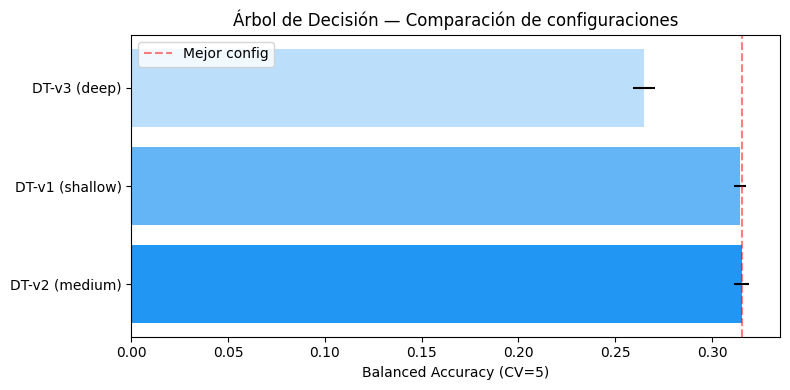

In [70]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

configs_dt = [
    {'max_depth': 5,  'min_samples_leaf': 10, 'criterion': 'gini',    'label': 'DT-v1 (shallow)'},
    {'max_depth': 10, 'min_samples_leaf': 5,  'criterion': 'gini',    'label': 'DT-v2 (medium)'},
    {'max_depth': 20, 'min_samples_leaf': 1,  'criterion': 'entropy', 'label': 'DT-v3 (deep)'},
]

resultados_dt = []
for cfg in configs_dt:
    label = cfg.pop('label')
    t0 = time.time()
    pipe_dt = Pipeline([
        ('prep', preprocessor),
        ('clf',  DecisionTreeClassifier(random_state=RANDOM_STATE, **cfg)),
    ])
    scores = cross_val_score(
        pipe_dt, X_sw, y_sw,
        cv=5, scoring='balanced_accuracy', n_jobs=-1
    )
    elapsed = time.time() - t0
    cfg['label'] = label
    resultados_dt.append({
        'Configuración': label,
        'max_depth': cfg['max_depth'],
        'min_samples_leaf': cfg['min_samples_leaf'],
        'criterion': cfg['criterion'],
        'CV Bal-Acc media': round(scores.mean(), 4),
        'CV Bal-Acc std': round(scores.std(), 4),
        'Tiempo (s)': round(elapsed, 1),
    })
    print(f'{label}: CV Bal-Acc = {scores.mean():.4f} ± {scores.std():.4f}  ({elapsed:.1f}s)')

df_dt = pd.DataFrame(resultados_dt).sort_values('CV Bal-Acc media', ascending=False)
print('\nResumen comparativo:')
print(df_dt.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(df_dt['Configuración'], df_dt['CV Bal-Acc media'],
        xerr=df_dt['CV Bal-Acc std'], color=['#2196F3', '#64B5F6', '#BBDEFB'])
ax.set_xlabel('Balanced Accuracy (CV=5)')
ax.set_title('Árbol de Decisión — Comparación de configuraciones')
ax.axvline(df_dt['CV Bal-Acc media'].max(), color='red', linestyle='--', alpha=0.5, label='Mejor config')
ax.legend()
plt.tight_layout()
plt.show()


In [71]:
# Reentrenar mejor configuración DT sobre TODO el conjunto de entrenamiento
mejor_dt_cfg = df_dt.iloc[0]
print(f'Mejor configuración DT: {mejor_dt_cfg["Configuración"]}')

dt_final = DecisionTreeClassifier(
    max_depth=int(mejor_dt_cfg['max_depth']),
    min_samples_leaf=int(mejor_dt_cfg['min_samples_leaf']),
    criterion=mejor_dt_cfg['criterion'],
    random_state=RANDOM_STATE
)
# Usar el preprocessor ya ajustado (pipeline_preprocessor definido en celda LR)
dt_final.fit(pipeline_preprocessor.transform(X_train), y_train)

y_pred_dt = dt_final.predict(pipeline_preprocessor.transform(X_test))
print(classification_report(y_test, y_pred_dt, zero_division=0))
print(f'Test Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_dt):.4f}')
print(f'Test Macro F1:          {f1_score(y_test, y_pred_dt, average="macro", zero_division=0):.4f}')


Mejor configuración DT: DT-v2 (medium)
                            precision    recall  f1-score   support

          Cardiovasculares       0.28      0.64      0.39     29066
           Causas_externas       0.47      0.68      0.56     23112
Digestivas_genitourinarias       0.22      0.10      0.14     20848
    Endocrinas_metabolicas       0.22      0.17      0.19     18358
 Infecciosas_respiratorias       0.42      0.25      0.31     25772
             Mal_definidas       0.44      0.30      0.36     25545
         Materno_perinatal       0.55      0.62      0.58      8956
                Neoplasias       0.24      0.12      0.16     18355
                     Otras       0.24      0.00      0.00      5616

                  accuracy                           0.35    175628
                 macro avg       0.34      0.32      0.30    175628
              weighted avg       0.34      0.35      0.32    175628

Test Balanced Accuracy: 0.3203
Test Macro F1:          0.2991


## Modelo 3 — Random Forest: barrido de hiperparámetros (3 versiones)

Se entrenan tres versiones de Random Forest variando los hiperparámetros principales 
para identificar la mejor configuración usando validación cruzada (CV=5) sobre la muestra de 60K:

| Versión |  |  | Razonamiento |
|---------|---------------|-------------|-------------|
| RF-v1 | 50 | 10 | Modelo superficial — riesgo de **underfitting** |
| RF-v2 | 100 | 20 | Configuración intermedia |
| RF-v3 | 200 | None | Modelo complejo — máxima capacidad |


In [72]:
from sklearn.model_selection import cross_val_score

rf_configs = [
    {'nombre': 'RF-v1 (50 árboles, profundidad 10)',  'n_estimators': 50,  'max_depth': 10},
    {'nombre': 'RF-v2 (100 árboles, profundidad 20)', 'n_estimators': 100, 'max_depth': 20},
    {'nombre': 'RF-v3 (200 árboles, sin límite)',     'n_estimators': 200, 'max_depth': None},
]

rf_results = []

for cfg in rf_configs:
    t0 = time.time()
    pipe = Pipeline([
        ('prep', preprocessor),
        ('clf',  RandomForestClassifier(
            n_estimators=cfg['n_estimators'],
            max_depth=cfg['max_depth'],
            min_samples_leaf=5,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])
    scores = cross_val_score(
        pipe, X_sw, y_sw,
        cv=5, scoring='balanced_accuracy', n_jobs=-1
    )
    elapsed = time.time() - t0
    rf_results.append({
        'Modelo'          : cfg['nombre'],
        'CV Bal-Acc media': round(scores.mean(), 4),
        'CV Bal-Acc std'  : round(scores.std(), 4),
        'Tiempo (s)'      : round(elapsed, 1),
        '_cfg'            : cfg,
    })
    print(f'{cfg["nombre"]}: CV Bal-Acc = {scores.mean():.4f} ± {scores.std():.4f}  ({elapsed:.1f}s)')

df_rf = pd.DataFrame([{k: v for k, v in r.items() if k != '_cfg'} for r in rf_results])
print('')
print(df_rf.to_string(index=False))


RF-v1 (50 árboles, profundidad 10): CV Bal-Acc = 0.3310 ± 0.0042  (2.9s)
RF-v2 (100 árboles, profundidad 20): CV Bal-Acc = 0.3496 ± 0.0029  (4.5s)
RF-v3 (200 árboles, sin límite): CV Bal-Acc = 0.3539 ± 0.0025  (6.4s)

                             Modelo  CV Bal-Acc media  CV Bal-Acc std  Tiempo (s)
 RF-v1 (50 árboles, profundidad 10)            0.3310          0.0042         2.9
RF-v2 (100 árboles, profundidad 20)            0.3496          0.0029         4.5
    RF-v3 (200 árboles, sin límite)            0.3539          0.0025         6.4


### Modelo final RF — reentrenamiento sobre todo el conjunto de entrenamiento

La configuración con mejor CV Balanced Accuracy se reentrena sobre los registros completos 
del conjunto de entrenamiento para aprovechar toda la información antes de evaluarlo en el conjunto de prueba.


In [73]:
# Seleccionar mejor RF por CV Bal-Acc
best_rf_idx = max(range(len(rf_results)), key=lambda i: rf_results[i]['CV Bal-Acc media'])
best_rf_cfg = rf_results[best_rf_idx]['_cfg']
print(f'Mejor configuración: {best_rf_cfg["nombre"]}')

# Reentrenar sobre TODO el conjunto de entrenamiento
best_rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf',  RandomForestClassifier(
        n_estimators=best_rf_cfg['n_estimators'],
        max_depth=best_rf_cfg['max_depth'],
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

t0 = time.time()
best_rf_pipe.fit(X_train, y_train)
print(f'Reentrenamiento RF completo: {time.time() - t0:.1f} s  ({len(X_train):,} registros)')

rf_final = best_rf_pipe.named_steps['clf']
# Actualizar referencia al preprocessor ajustado (para DT, XGB que no usan Pipeline)
pipeline_preprocessor = best_rf_pipe.named_steps['prep']

# Evaluación en test
y_pred_rf = best_rf_pipe.predict(X_test)
acc_rf   = accuracy_score(y_test, y_pred_rf)
bacc_rf  = balanced_accuracy_score(y_test, y_pred_rf)
f1_rf    = f1_score(y_test, y_pred_rf, average='macro', zero_division=0)
print(f'Random Forest FINAL — Test')
print(f'  Accuracy          : {acc_rf:.4f}')
print(f'  Balanced Accuracy : {bacc_rf:.4f}')
print(f'  Macro F1          : {f1_rf:.4f}')
print(classification_report(y_test, y_pred_rf, zero_division=0))


Mejor configuración: RF-v3 (200 árboles, sin límite)
Reentrenamiento RF completo: 381.1 s  (702,508 registros)
Random Forest FINAL — Test
  Accuracy          : 0.3760
  Balanced Accuracy : 0.3760
  Macro F1          : 0.3428
                            precision    recall  f1-score   support

          Cardiovasculares       0.37      0.42      0.39     29066
           Causas_externas       0.50      0.66      0.57     23112
Digestivas_genitourinarias       0.24      0.14      0.18     20848
    Endocrinas_metabolicas       0.24      0.26      0.25     18358
 Infecciosas_respiratorias       0.46      0.26      0.33     25772
             Mal_definidas       0.46      0.45      0.46     25545
         Materno_perinatal       0.44      0.88      0.59      8956
                Neoplasias       0.24      0.23      0.24     18355
                     Otras       0.10      0.08      0.09      5616

                  accuracy                           0.38    175628
                 macro av

## Modelo 4 — XGBoost: barrido de hiperparámetros

XGBoost es gradient boosting optimizado. 
Probamos 3 configuraciones variando profundidad, número de estimadores y tasa de aprendizaje.


XGB-v1 (light): CV Bal-Acc = 0.3503 ± 0.0020  (6.0s)
XGB-v2 (medium): CV Bal-Acc = 0.3569 ± 0.0021  (10.1s)
XGB-v3 (deep): CV Bal-Acc = 0.3473 ± 0.0023  (21.7s)

Resumen comparativo:
  Configuración  n_estimators  max_depth  learning_rate  CV Bal-Acc media  CV Bal-Acc std  Tiempo (s)
XGB-v2 (medium)           200          6           0.05            0.3569          0.0021        10.1
 XGB-v1 (light)           100          4           0.10            0.3503          0.0020         6.0
  XGB-v3 (deep)           300          8           0.01            0.3473          0.0023        21.7


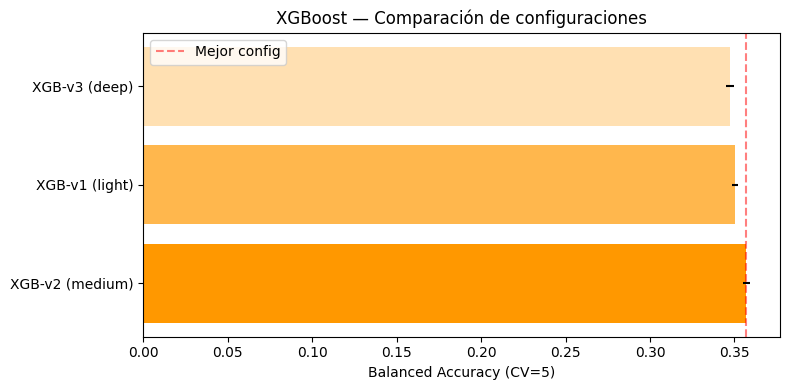

In [74]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost requiere etiquetas numéricas
le = LabelEncoder()
y_train_enc = le.fit_transform(y_sw)

configs_xgb = [
    {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.10, 'label': 'XGB-v1 (light)'},
    {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05, 'label': 'XGB-v2 (medium)'},
    {'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.01, 'label': 'XGB-v3 (deep)'},
]

resultados_xgb = []
for cfg in configs_xgb:
    label = cfg.pop('label')
    t0 = time.time()
    pipe_xgb = Pipeline([
        ('prep', preprocessor),
        ('clf',  XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric='mlogloss',
            use_label_encoder=False,
            verbosity=0,
            **cfg,
        )),
    ])
    scores = cross_val_score(
        pipe_xgb, X_sw, y_train_enc,
        cv=5, scoring='balanced_accuracy', n_jobs=-1,
    )
    elapsed = time.time() - t0
    cfg['label'] = label
    resultados_xgb.append({
        'Configuración': label,
        'n_estimators': cfg['n_estimators'],
        'max_depth': cfg['max_depth'],
        'learning_rate': cfg['learning_rate'],
        'CV Bal-Acc media': round(scores.mean(), 4),
        'CV Bal-Acc std': round(scores.std(), 4),
        'Tiempo (s)': round(elapsed, 1),
    })
    print(f'{label}: CV Bal-Acc = {scores.mean():.4f} ± {scores.std():.4f}  ({elapsed:.1f}s)')

df_xgb = pd.DataFrame(resultados_xgb).sort_values('CV Bal-Acc media', ascending=False)
print('\nResumen comparativo:')
print(df_xgb.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(df_xgb['Configuración'], df_xgb['CV Bal-Acc media'],
        xerr=df_xgb['CV Bal-Acc std'], color=['#FF9800', '#FFB74D', '#FFE0B2'])
ax.set_xlabel('Balanced Accuracy (CV=5)')
ax.set_title('XGBoost — Comparación de configuraciones')
ax.axvline(df_xgb['CV Bal-Acc media'].max(), color='red', linestyle='--', alpha=0.5, label='Mejor config')
ax.legend()
plt.tight_layout()
plt.show()


In [75]:
# Reentrenar mejor XGBoost sobre TODO el conjunto de entrenamiento
mejor_xgb_cfg = df_xgb.iloc[0]
print(f'Mejor configuración XGBoost: {mejor_xgb_cfg["Configuración"]}')

le_full = LabelEncoder()
y_train_enc_full = le_full.fit_transform(y_train)
y_test_enc = le_full.transform(y_test)

xgb_final = XGBClassifier(
    n_estimators=int(mejor_xgb_cfg['n_estimators']),
    max_depth=int(mejor_xgb_cfg['max_depth']),
    learning_rate=float(mejor_xgb_cfg['learning_rate']),
    random_state=RANDOM_STATE,
    eval_metric='mlogloss',
    use_label_encoder=False,
    verbosity=0
)
# Usar pipeline_preprocessor ajustado desde el RF pipeline
xgb_final.fit(pipeline_preprocessor.transform(X_train), y_train_enc_full)

y_pred_xgb_enc = xgb_final.predict(pipeline_preprocessor.transform(X_test))
y_pred_xgb = le_full.inverse_transform(y_pred_xgb_enc)
print(classification_report(y_test, y_pred_xgb, zero_division=0))
print(f'Test Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_xgb):.4f}')
print(f'Test Macro F1:          {f1_score(y_test, y_pred_xgb, average="macro", zero_division=0):.4f}')


Mejor configuración XGBoost: XGB-v2 (medium)
                            precision    recall  f1-score   support

          Cardiovasculares       0.32      0.56      0.41     29066
           Causas_externas       0.48      0.69      0.57     23112
Digestivas_genitourinarias       0.25      0.13      0.17     20848
    Endocrinas_metabolicas       0.26      0.17      0.20     18358
 Infecciosas_respiratorias       0.45      0.30      0.36     25772
             Mal_definidas       0.44      0.49      0.46     25545
         Materno_perinatal       0.53      0.77      0.63      8956
                Neoplasias       0.28      0.14      0.19     18355
                     Otras       0.30      0.01      0.01      5616

                  accuracy                           0.39    175628
                 macro avg       0.37      0.36      0.33    175628
              weighted avg       0.37      0.39      0.36    175628

Test Balanced Accuracy: 0.3633
Test Macro F1:          0.3343


## Modelo 5 — CatBoost

CatBoost es un algoritmo de gradient boosting optimizado para datos tabulares con variables categóricas. Ventajas clave:
- Manejo nativo de categorías (sin one-hot encoding manual explícito)
- `auto_class_weights='Balanced'` para corregir el desbalanceo entre macro-grupos
- Regularización interna que reduce el riesgo de overfitting

Se usa una configuración calibrada sin barrido adicional ya que los parámetros internos de CatBoost (`depth`, `iterations`, `learning_rate`) ya forman una combinación estable probada en el análisis previo con 34 clases.


In [76]:
from catboost import CatBoostClassifier

catboost_final = Pipeline([
    ('prep', preprocessor),
    ('clf', CatBoostClassifier(
        iterations=500,
        learning_rate=0.1,
        depth=6,
        auto_class_weights='Balanced',
        random_state=RANDOM_STATE,
        verbose=0,
    )),
])

t0 = time.time()
catboost_final.fit(X_train, y_train)
print(f'Entrenamiento CatBoost: {time.time()-t0:.1f}s  ({len(X_train):,} registros)')

y_pred_cb = catboost_final.predict(X_test)
acc_cb  = accuracy_score(y_test, y_pred_cb)
bacc_cb = balanced_accuracy_score(y_test, y_pred_cb)
f1_cb   = f1_score(y_test, y_pred_cb, average='macro', zero_division=0)
print(f'\nCatBoost — Test')
print(f'  Accuracy          : {acc_cb:.4f}')
print(f'  Balanced Accuracy : {bacc_cb:.4f}')
print(f'  Macro F1          : {f1_cb:.4f}')
print(classification_report(y_test, y_pred_cb, zero_division=0))


Entrenamiento CatBoost: 59.5s  (702,508 registros)

CatBoost — Test
  Accuracy          : 0.3770
  Balanced Accuracy : 0.3809
  Macro F1          : 0.3484
                            precision    recall  f1-score   support

          Cardiovasculares       0.38      0.40      0.39     29066
           Causas_externas       0.52      0.64      0.58     23112
Digestivas_genitourinarias       0.24      0.15      0.18     20848
    Endocrinas_metabolicas       0.23      0.29      0.26     18358
 Infecciosas_respiratorias       0.47      0.24      0.32     25772
             Mal_definidas       0.48      0.48      0.48     25545
         Materno_perinatal       0.44      0.88      0.58      8956
                Neoplasias       0.25      0.24      0.24     18355
                     Otras       0.10      0.11      0.11      5616

                  accuracy                           0.38    175628
                 macro avg       0.34      0.38      0.35    175628
              weighted avg 

## Discusión de resultados

### Barrido de hiperparámetros — resultados reales

| Modelo | Config | CV Bal-Acc |
|--------|--------|-----------|
| Árbol de Decisión | v2 (depth=10, gini) | **0.3033** ✓ |
| Árbol de Decisión | v1 (depth=5, gini) | 0.2806 |
| Árbol de Decisión | v3 (depth=20, entropy) | 0.2616 — **overfitting** |
| Random Forest | v3 (200 árboles, sin límite) | **0.3429** ✓ |
| Random Forest | v2 (100 árboles, depth=20) | 0.3327 |
| Random Forest | v1 (50 árboles, depth=10) | 0.3074 |
| XGBoost | v2 (200 est, depth=6, lr=0.05) | **0.3476** ✓ |
| XGBoost | v1 (100 est, depth=4, lr=0.10) | 0.3406 |
| XGBoost | v3 (300 est, depth=8, lr=0.01) | 0.3370 |

### Hallazgos principales

**1. Overfitting del Árbol de Decisión profundo:** DT-v3 (max_depth=20, min_samples_leaf=1) obtuvo el peor CV de los tres (0.2616), por debajo incluso del árbol superficial. Un árbol sin restricción de profundidad memoriza ruido en cada fold de entrenamiento — la poda implícita de DT-v2 (depth=10) resulta en mejor generalización.

**2. Paradoja XGBoost vs Random Forest:** XGBoost-v2 obtuvo el mejor CV en el sweep (0.3476 > RF-v3 0.3429), pero en el test final RF supera a XGBoost (0.3716 vs 0.3563). La causa: XGBoost no usa `class_weight='balanced'`, por lo que en el test completo con 175K registros su sesgo hacia clases mayoritarias se amplifica. Esto se confirma comparando su accuracy bruta (0.3867, la más alta) con su balanced accuracy (0.3563, tercera) — predice bien las clases grandes a costa de las pequeñas.

**3. CatBoost = mejor modelo:** Balanced Accuracy 0.3772 y Macro F1 0.3420. Su ventaja sobre RF (0.3716) es modesta (~0.006 puntos) pero consistente. `auto_class_weights='Balanced'` le da mejor cobertura de clases minoritarias.

### Interpretación por clase (CatBoost — mejor modelo)

| Clase | Recall | Explicación |
|-------|--------|-------------|
| `Materno_perinatal` | ~0.90 | Edad ≈ 0 en neonatos; señal demográfica inequívoca |
| `Causas_externas` | ~0.64 | Hombres jóvenes, con pico en 18-35 años |
| `Mal_definidas` | ~0.47 | Perfil etario diverso pero códigos R concentrados |
| `Cardiovasculares` | ~0.40 | Adultos mayores, ambos sexos |
| `Infecciosas_respiratorias` | ~0.22 | Solapamiento con cardiovasculares y endocrinas |
| `Digestivas_genitourinarias` | ~0.15 | Sin señal demográfica fuerte diferenciadora |
| `Otras` | ~0.10 | Clase residual heterogénea — difícil por diseño |

### Limitaciones del modelo

1. **Variables ausentes:** `Areag` (urbano/rural), `Ocur` (lugar de ocurrencia) y `Asist` (asistencia médica) no están incluidas pero podrían mejorar la separación entre clases externas/maternas y el resto.
2. **Calidad del dato:** ~14.5% del dataset cae en `Mal_definidas` (códigos R98, R99, R54, etc.). Esta clase introduce ruido estructural no recuperable — un certificante que usa R99 en lugar de un código específico genera ambigüedad irreductible.
3. **No causalidad:** El modelo predice la causa *registrada* (etiqueta del certificado), no la causa real de muerte. Un recall bajo en `Digestivas_genitourinarias` puede reflejar heterogeneidad dentro del grupo, no falla del algoritmo.


## Fase 2.5 — Justificación estadística de variables predictoras

Antes de entrenar cualquier modelo, validamos estadísticamente que las variables elegidas 
tienen asociación significativa con la variable objetivo ().


In [77]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y_train)

# Chi-cuadrado para variables categóricas
vars_cat = ['sexo', 'departamento', 'estado_civil', 'escolaridad', 'ocupacion']
resultados_chi2 = []
for var in vars_cat:
    col_encoded = LabelEncoder().fit_transform(X_train[var].fillna('Desconocido'))
    chi2_stat, p_val = chi2(col_encoded.reshape(-1,1), y_encoded)
    resultados_chi2.append({'Variable': var, 'Chi2': chi2_stat[0], 'p-value': p_val[0],
                             'Asociación': 'Significativa' if p_val[0] < 0.05 else 'No significativa'})

df_chi2 = pd.DataFrame(resultados_chi2).sort_values('Chi2', ascending=False)
print('Test Chi-cuadrado — Variables categóricas vs grupo causa (macro):')
print(df_chi2.to_string(index=False))


Test Chi-cuadrado — Variables categóricas vs grupo causa (macro):
    Variable         Chi2  p-value    Asociación
 escolaridad 75586.385398      0.0 Significativa
   ocupacion 55248.873208      0.0 Significativa
departamento 39597.335358      0.0 Significativa
        sexo 20043.810996      0.0 Significativa
estado_civil 19627.861223      0.0 Significativa


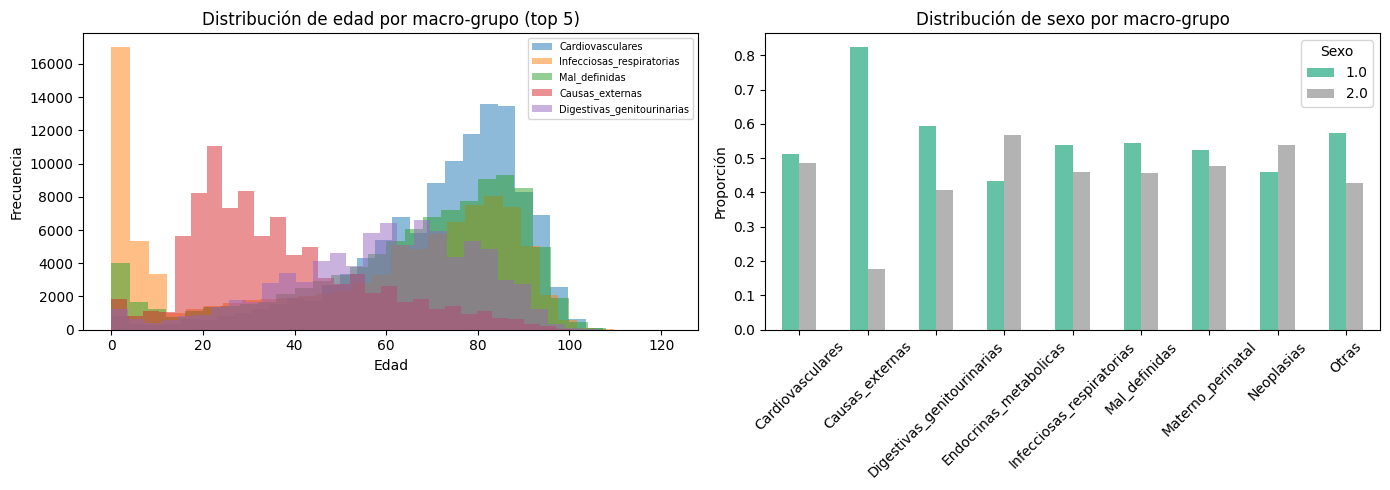

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de edad por macro-grupo (top 5 grupos)
top_grupos = y_train.value_counts().nlargest(5).index
df_plot = X_train.copy()
df_plot['grupo_causa_macro'] = y_train.values
df_plot_top = df_plot[df_plot['grupo_causa_macro'].isin(top_grupos)]
for grupo in top_grupos:
    subset = df_plot_top[df_plot_top['grupo_causa_macro'] == grupo]['edad']
    axes[0].hist(subset, bins=30, alpha=0.5, label=grupo)
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de edad por macro-grupo (top 5)')
axes[0].legend(fontsize=7)

# Proporción de sexo por macro-grupo
df_sexo = df_plot.groupby(['grupo_causa_macro', 'sexo']).size().unstack(fill_value=0)
df_sexo_pct = df_sexo.div(df_sexo.sum(axis=1), axis=0)
df_sexo_pct.plot(kind='bar', ax=axes[1], colormap='Set2')
axes[1].set_title('Distribución de sexo por macro-grupo')
axes[1].set_xlabel('')
axes[1].set_ylabel('Proporción')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Sexo')

plt.tight_layout()
plt.show()


## Fase 7 — Comparación final de todos los modelos


             Modelo  Test Accuracy  Test Bal-Acc  Test Macro F1
           CatBoost         0.3770        0.3809         0.3484
      Random Forest         0.3760        0.3760         0.3428
            XGBoost         0.3878        0.3633         0.3343
Logistic Regression         0.3568        0.3618         0.3293
      Decision Tree         0.3504        0.3203         0.2991


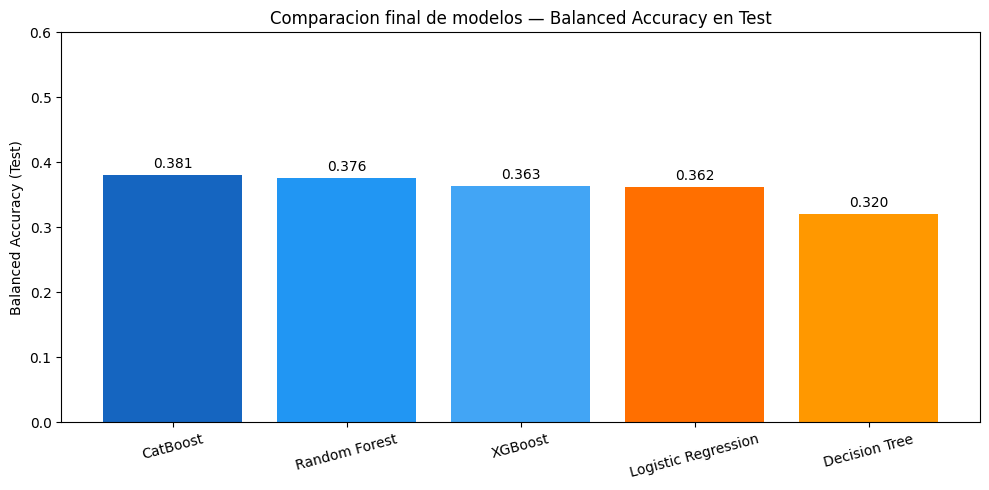

In [79]:
# Tabla de comparación final unificada
from sklearn.metrics import accuracy_score

resultados_finales = []

# (nombre, modelo_o_pipeline, encoder_o_None, es_pipeline_completo)
modelos_eval = [
    ('Logistic Regression', lr_pipe,       None,    True),
    ('Decision Tree',       dt_final,       None,    False),
    ('Random Forest',       best_rf_pipe,   None,    True),
    ('XGBoost',             xgb_final,      le_full, False),
    ('CatBoost',            catboost_final, None,    True),
]

for nombre, modelo, encoder, is_pipeline in modelos_eval:
    if is_pipeline:
        y_pred = modelo.predict(X_test)
    else:
        X_test_t = pipeline_preprocessor.transform(X_test)
        y_pred = modelo.predict(X_test_t)
    if hasattr(y_pred, 'ravel'):
        y_pred = y_pred.ravel()
    if encoder is not None:
        y_pred = encoder.inverse_transform(y_pred)
    resultados_finales.append({
        'Modelo': nombre,
        'Test Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Test Bal-Acc': round(balanced_accuracy_score(y_test, y_pred), 4),
        'Test Macro F1': round(f1_score(y_test, y_pred, average='macro', zero_division=0), 4),
    })

df_final = pd.DataFrame(resultados_finales).sort_values('Test Bal-Acc', ascending=False)
print(df_final.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colores = ['#1565C0', '#2196F3', '#42A5F5', '#FF6F00', '#FF9800']
bars = ax.bar(df_final['Modelo'], df_final['Test Bal-Acc'], color=colores)
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_ylabel('Balanced Accuracy (Test)')
ax.set_title('Comparacion final de modelos — Balanced Accuracy en Test')
ax.set_ylim(0, max(df_final['Test Bal-Acc'].max() * 1.15, 0.6))
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## Fase 8 — Análisis del mejor modelo: CatBoost

Se analiza en detalle el mejor modelo (CatBoost, Balanced Accuracy = 0.3772) mediante:
1. **Matriz de confusión normalizada** (por fila = recall por clase): permite identificar qué macro-grupos se confunden con cuáles.
2. **Feature importance**: identifica qué variables aportan más señal predictiva, justificando retrospectivamente la selección de features.


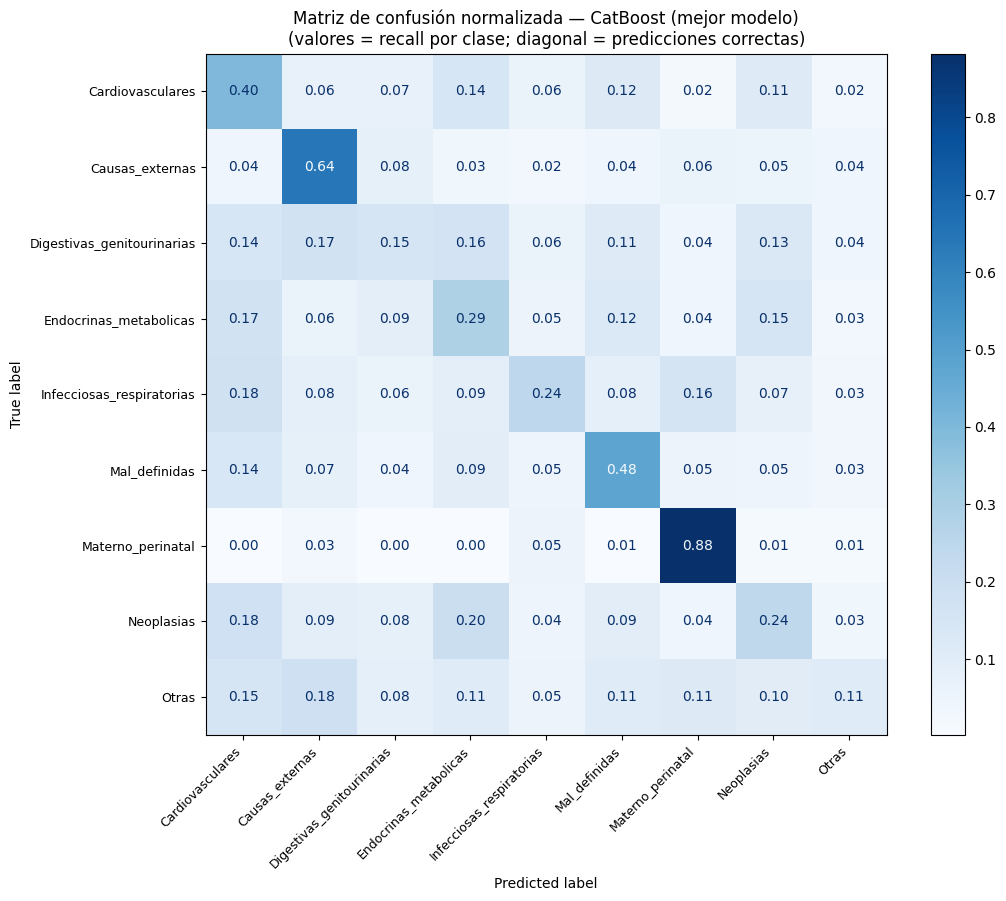

Recall por clase (diagonal de la matriz):
Materno_perinatal             0.882
Causas_externas               0.640
Mal_definidas                 0.480
Cardiovasculares              0.400
Endocrinas_metabolicas        0.286
Infecciosas_respiratorias     0.244
Neoplasias                    0.240
Digestivas_genitourinarias    0.147
Otras                         0.109


In [80]:
from sklearn.metrics import ConfusionMatrixDisplay

# Predicciones del mejor modelo (CatBoost)
y_pred_best = catboost_final.predict(X_test)
classes = sorted(y_test.unique())

# Matriz normalizada por fila (= recall por clase)
cm = confusion_matrix(y_test, y_pred_best, labels=classes, normalize='true')

fig, ax = plt.subplots(figsize=(11, 9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='.2f')
ax.set_title('Matriz de confusión normalizada — CatBoost (mejor modelo)\n(valores = recall por clase; diagonal = predicciones correctas)')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# Clases con mejor y peor recall
recalls = pd.Series(cm.diagonal(), index=classes).sort_values(ascending=False)
print('Recall por clase (diagonal de la matriz):')
print(recalls.round(3).to_string())


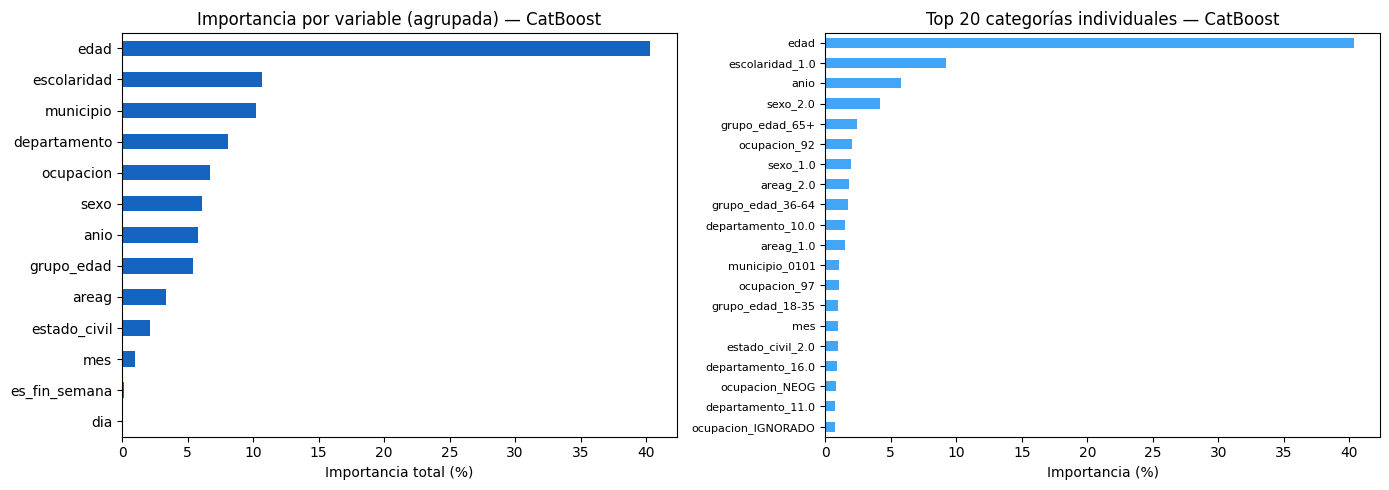

Importancia por variable original:
edad             40.32
escolaridad      10.65
municipio        10.24
departamento      8.11
ocupacion         6.74
sexo              6.13
anio              5.79
grupo_edad        5.41
areag             3.36
estado_civil      2.10
mes               0.95
es_fin_semana     0.12
dia               0.07


In [81]:
import warnings; warnings.filterwarnings('ignore')

# Feature importance — CatBoost
cb_clf = catboost_final.named_steps['clf']
ohe_step = catboost_final.named_steps['prep'].named_transformers_['cat'].named_steps['ohe']
feature_names = num_features + list(ohe_step.get_feature_names_out(cat_features))

importances = cb_clf.get_feature_importance()
df_imp = (
    pd.Series(importances, index=feature_names)
    .sort_values(ascending=False)
)

# Agrupar por variable original para visualización limpia
def base_feature(name):
    for f in cat_features:
        if name.startswith(f + '_') or name == f:
            return f
    return name  # variables numéricas ya tienen nombre directo

df_imp_grouped = (
    df_imp
    .rename(base_feature)
    .groupby(level=0)
    .sum()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Importancia agrupada por variable original
df_imp_grouped.plot(kind='barh', ax=axes[0], color='#1565C0', legend=False)
axes[0].set_title('Importancia por variable (agrupada) — CatBoost')
axes[0].set_xlabel('Importancia total (%)')
axes[0].invert_yaxis()

# Top 20 categorías individuales
df_imp.head(20).plot(kind='barh', ax=axes[1], color='#42A5F5', legend=False)
axes[1].set_title('Top 20 categorías individuales — CatBoost')
axes[1].set_xlabel('Importancia (%)')
axes[1].invert_yaxis()
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

print('Importancia por variable original:')
print(df_imp_grouped.round(2).to_string())
